In [1]:
# Parameters
run_id = "130b4b0c-059c-4a33-880b-6e04c41ce18c"
artifacts_dir = "/home/adnoman/projects/aml_gan/AMLend2end/artifacts/runs/130b4b0c-059c-4a33-880b-6e04c41ce18c"
sample_size = None
epochs = None
threshold = None


# AML Graph Visualization & Results Analysis

This notebook visualizes:
1. The transaction network graph (nodes and edges)
2. Anomaly detection results
3. Distribution of anomaly scores
4. **Transaction value/money flow analysis**
5. Highlighted suspicious nodes with financial impact

In [2]:
# Setup and imports
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from tensorflow import keras
from matplotlib.lines import Line2D

# Define paths
BASE_PATH = os.path.dirname(os.path.abspath("__file__"))
TRAINING_DATA_PATH = os.path.join(BASE_PATH, "training_data")
OUTPUT_PATH = os.path.join(BASE_PATH, "output")
MODELS_PATH = os.path.join(BASE_PATH, "models")

# Set plot style
plt.style.use('default')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded successfully!")

2026-02-02 16:21:24.294423: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-02 16:21:24.325477: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-02-02 16:21:25.118875: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Libraries loaded successfully!


## 1. Load Data

In [3]:
# Load edges (transactions)
edges_df = pd.read_csv(os.path.join(TRAINING_DATA_PATH, "edges_td.csv"))
print(f"Loaded {len(edges_df)} edges (transactions)")
print(f"Edge columns: {edges_df.columns.tolist()}")
edges_df.head()

Loaded 438386 edges (transactions)
Edge columns: ['source', 'target', 'tran_id', 'tx_type', 'base_amt']


,source,target,tran_id,tx_type,base_amt
0,3aa9646b,1e46e726,496,4,858.77
1,49203bc3,a74d1101,1342,4,386.86
2,616d4505,99af2455,1580,4,616.43
3,39be1ea2,e7ec7bdb,2866,4,146.44
4,e2e0d938,afc399a9,3997,4,439.09


In [4]:
# Load nodes (parties)
nodes_df = pd.read_csv(os.path.join(TRAINING_DATA_PATH, "node_td.csv"))
print(f"Loaded {len(nodes_df)} nodes (parties)")
print(f"Node columns: {nodes_df.columns.tolist()}")
nodes_df.head()

Loaded 7347 nodes (parties)
Node columns: ['id', 'type']


,id,type
0,5628bd6c,0
1,a1fcba39,0
2,f56c9501,1
3,9969afdd,0
4,b356eeae,1


In [5]:
# Load node embeddings with anomaly scores
node_embeddings = pd.read_parquet(os.path.join(OUTPUT_PATH, "node_embeddings_fg.parquet"))
print(f"Loaded {len(node_embeddings)} node embeddings")

# Load the trained model to compute anomaly scores
model_dirs = [d for d in os.listdir(MODELS_PATH) if d.startswith('gan_anomaly_')]
latest_model_dir = os.path.join(MODELS_PATH, sorted(model_dirs)[-1])
model = keras.models.load_model(os.path.join(latest_model_dir, "anomaly_detector.keras"))
threshold = np.load(os.path.join(latest_model_dir, "threshold.npy"))

print(f"Model loaded from: {latest_model_dir}")
print(f"Anomaly threshold: {threshold:.6f}")

Loaded 7347 node embeddings


I0000 00:00:1770031285.730256   96521 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9511 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model loaded from: /home/adnoman/projects/aml_gan/AMLend2end/models/gan_anomaly_5f5ae592
Anomaly threshold: 0.000152


In [6]:
# Compute anomaly scores for all nodes
emb_cols = [c for c in node_embeddings.columns if c.startswith('emb_')]
all_embeddings = node_embeddings[emb_cols].values
reconstructed = model.predict(all_embeddings, verbose=0)
anomaly_scores = np.mean(np.square(all_embeddings - reconstructed), axis=1)

# Add to dataframe
node_embeddings['anomaly_score'] = anomaly_scores
node_embeddings['is_anomaly'] = anomaly_scores > threshold

print(f"Anomaly scores computed!")
print(f"Score range: [{anomaly_scores.min():.6f}, {anomaly_scores.max():.6f}]")
print(f"Threshold: {threshold:.6f}")

2026-02-02 16:21:26.478318: I external/local_xla/xla/service/service.cc:163] XLA service 0x779740003520 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-02 16:21:26.478339: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-02-02 16:21:26.482428: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-02 16:21:26.499020: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801


I0000 00:00:1770031286.883017   96737 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Anomaly scores computed!
Score range: [0.000109, 0.000475]
Threshold: 0.000152


In [7]:
# Create NetworkX graph
G = nx.from_pandas_edgelist(
    edges_df,
    source='source',
    target='target',
    create_using=nx.DiGraph()
)

print(f"Graph Statistics:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Density: {nx.density(G):.4f}")
print(f"  Is connected: {nx.is_weakly_connected(G)}")
print(f"  Number of connected components: {nx.number_weakly_connected_components(G)}")

Graph Statistics:
  Nodes: 7347
  Edges: 17070
  Density: 0.0003
  Is connected: False
  Number of connected components: 5


## 2. Build Network Graph

## 2.5 Transaction Value Analysis

Transaction Amount Statistics:
Total transactions: 438,386
Total transaction value: $242,434,979.01
Average transaction: $553.02
Median transaction: $549.36
Min transaction: $43.32
Max transaction: $2,995.02


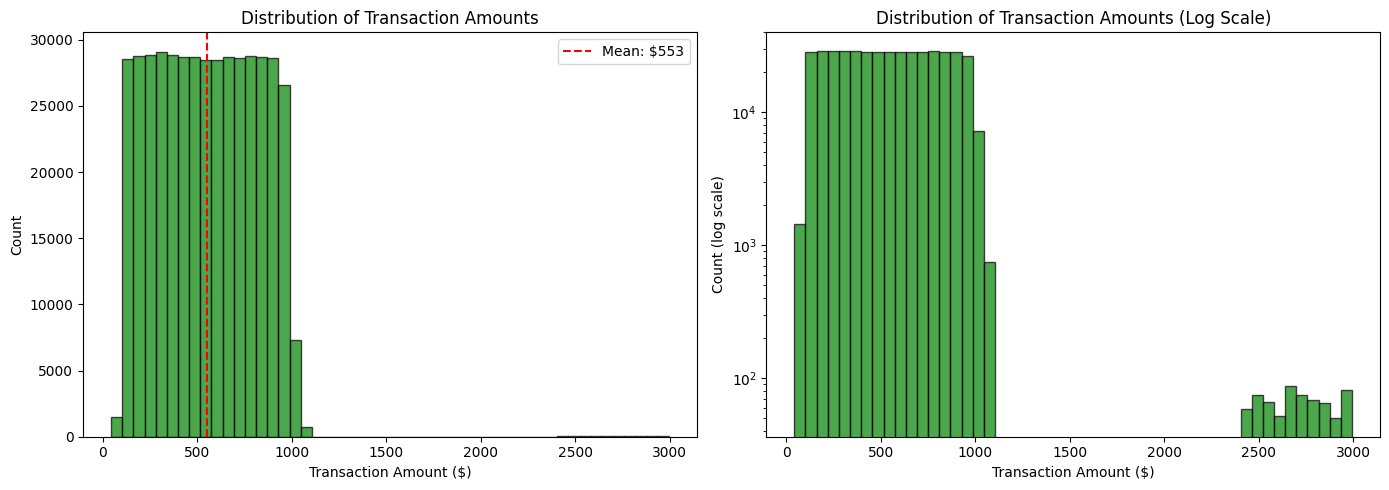

In [8]:
# Transaction amount analysis
print("Transaction Amount Statistics:")
print("=" * 50)
print(f"Total transactions: {len(edges_df):,}")
print(f"Total transaction value: ${edges_df['base_amt'].sum():,.2f}")
print(f"Average transaction: ${edges_df['base_amt'].mean():,.2f}")
print(f"Median transaction: ${edges_df['base_amt'].median():,.2f}")
print(f"Min transaction: ${edges_df['base_amt'].min():,.2f}")
print(f"Max transaction: ${edges_df['base_amt'].max():,.2f}")
print("=" * 50)

# Transaction amount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(edges_df['base_amt'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Transaction Amounts')
axes[0].axvline(x=edges_df['base_amt'].mean(), color='red', linestyle='--', label=f"Mean: ${edges_df['base_amt'].mean():,.0f}")
axes[0].legend()

# Log scale histogram for better visibility
axes[1].hist(edges_df['base_amt'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Transaction Amount ($)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Distribution of Transaction Amounts (Log Scale)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'transaction_amounts.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Calculate money flow per node
outgoing_amounts = edges_df.groupby('source')['base_amt'].sum().rename('outgoing_amt')
incoming_amounts = edges_df.groupby('target')['base_amt'].sum().rename('incoming_amt')
outgoing_counts = edges_df.groupby('source').size().rename('outgoing_count')
incoming_counts = edges_df.groupby('target').size().rename('incoming_count')

# Merge with node embeddings
node_money = node_embeddings[['id', 'anomaly_score', 'is_anomaly']].copy()
if 'is_sar' in node_embeddings.columns:
    node_money['is_sar'] = node_embeddings['is_sar']

node_money = node_money.merge(outgoing_amounts, left_on='id', right_index=True, how='left')
node_money = node_money.merge(incoming_amounts, left_on='id', right_index=True, how='left')
node_money = node_money.merge(outgoing_counts, left_on='id', right_index=True, how='left')
node_money = node_money.merge(incoming_counts, left_on='id', right_index=True, how='left')
node_money = node_money.fillna(0)

# Calculate total volume and net flow
node_money['total_volume'] = node_money['outgoing_amt'] + node_money['incoming_amt']
node_money['net_flow'] = node_money['incoming_amt'] - node_money['outgoing_amt']
node_money['total_transactions'] = node_money['outgoing_count'] + node_money['incoming_count']

print("Money Flow Statistics:")
print("=" * 50)
print(f"Total money volume: ${node_money['total_volume'].sum()/2:,.2f}")  # Divide by 2 to avoid double counting
print(f"Avg volume per node: ${node_money['total_volume'].mean():,.2f}")
print(f"Max volume (single node): ${node_money['total_volume'].max():,.2f}")
print("=" * 50)

Money Flow Statistics:
Total money volume: $242,434,979.01
Avg volume per node: $65,995.64
Max volume (single node): $452,657.49


Money Flow Comparison: Anomalous vs Normal Nodes
Metric                               Anomalous          Normal
------------------------------------------------------------
Node Count                               7,304              43
Total Volume ($)                   482,082,124       2,787,834
Avg Volume per Node ($)                 66,002          64,833
Avg Transactions per Node                119.4           116.1
Avg Outgoing ($)                        32,986          35,083
Avg Incoming ($)                        33,017          29,750


/tmp/ipykernel_96521/2618099287.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot([anomalous_money['total_volume'], normal_money['total_volume']],
/tmp/ipykernel_96521/2618099287.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot([anomalous_money['total_transactions'], normal_money['total_transactions']],


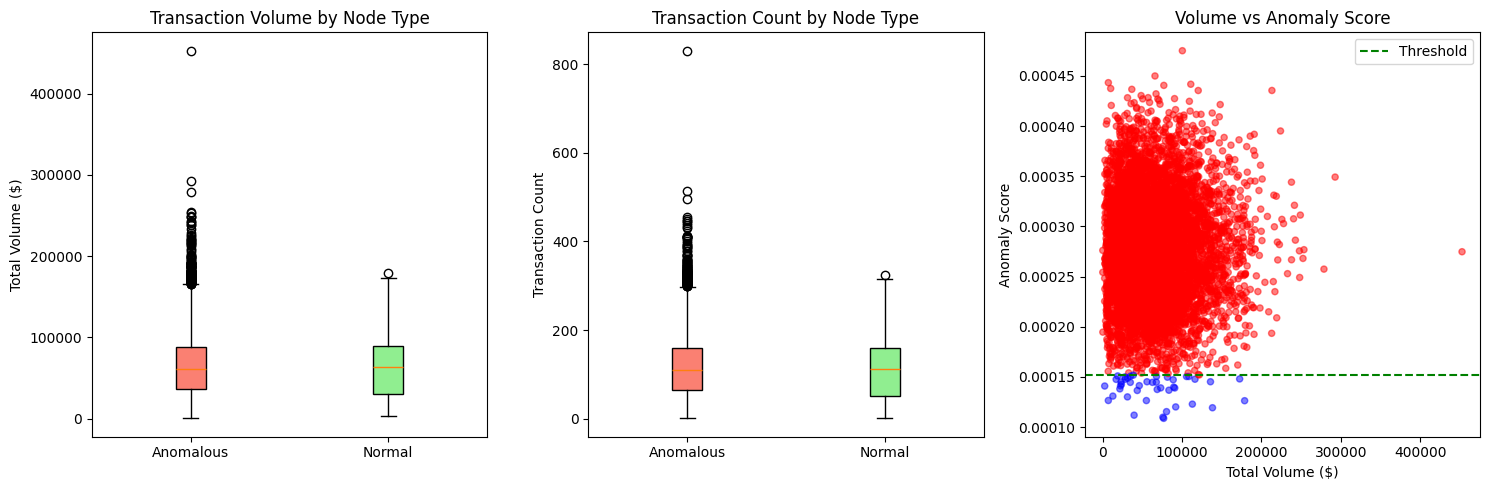

In [10]:
# Compare money flow: Anomalous vs Normal nodes
anomalous_money = node_money[node_money['is_anomaly'] == True]
normal_money = node_money[node_money['is_anomaly'] == False]

print("Money Flow Comparison: Anomalous vs Normal Nodes")
print("=" * 60)
print(f"{'Metric':<30} {'Anomalous':>15} {'Normal':>15}")
print("-" * 60)
print(f"{'Node Count':<30} {len(anomalous_money):>15,} {len(normal_money):>15,}")
print(f"{'Total Volume ($)':<30} {anomalous_money['total_volume'].sum():>15,.0f} {normal_money['total_volume'].sum():>15,.0f}")
print(f"{'Avg Volume per Node ($)':<30} {anomalous_money['total_volume'].mean():>15,.0f} {normal_money['total_volume'].mean():>15,.0f}")
print(f"{'Avg Transactions per Node':<30} {anomalous_money['total_transactions'].mean():>15,.1f} {normal_money['total_transactions'].mean():>15,.1f}")
print(f"{'Avg Outgoing ($)':<30} {anomalous_money['outgoing_amt'].mean():>15,.0f} {normal_money['outgoing_amt'].mean():>15,.0f}")
print(f"{'Avg Incoming ($)':<30} {anomalous_money['incoming_amt'].mean():>15,.0f} {normal_money['incoming_amt'].mean():>15,.0f}")
print("=" * 60)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Box plot of total volume
bp1 = axes[0].boxplot([anomalous_money['total_volume'], normal_money['total_volume']], 
                       labels=['Anomalous', 'Normal'], patch_artist=True)
bp1['boxes'][0].set_facecolor('salmon')
bp1['boxes'][1].set_facecolor('lightgreen')
axes[0].set_ylabel('Total Volume ($)')
axes[0].set_title('Transaction Volume by Node Type')

# Box plot of transaction count
bp2 = axes[1].boxplot([anomalous_money['total_transactions'], normal_money['total_transactions']], 
                       labels=['Anomalous', 'Normal'], patch_artist=True)
bp2['boxes'][0].set_facecolor('salmon')
bp2['boxes'][1].set_facecolor('lightgreen')
axes[1].set_ylabel('Transaction Count')
axes[1].set_title('Transaction Count by Node Type')

# Scatter: Volume vs Anomaly Score
scatter = axes[2].scatter(node_money['total_volume'], node_money['anomaly_score'], 
                          c=node_money['is_anomaly'].map({True: 'red', False: 'blue'}),
                          alpha=0.5, s=20)
axes[2].set_xlabel('Total Volume ($)')
axes[2].set_ylabel('Anomaly Score')
axes[2].set_title('Volume vs Anomaly Score')
axes[2].axhline(y=threshold, color='green', linestyle='--', label='Threshold')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'money_flow_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

Top 20 Suspicious Nodes by Transaction Volume:
      id  is_sar  total_volume  outgoing_amt  incoming_amt  total_transactions  anomaly_score
acd60eca       1     452657.49     157742.99     294914.50               830.0       0.000275
bdc39a68       0     292824.40     102375.41     190448.99               514.0       0.000349
53f24d0d       0     278756.55     112136.50     166620.05               495.0       0.000257
fb1904f6       0     253570.47      64382.92     189187.55               455.0       0.000277
e16513a0       0     252343.79      81579.36     170764.43               447.0       0.000268
e67f35bf       1     249010.29      73083.21     175927.08               411.0       0.000311
d195d055       0     248172.50      56284.56     191887.94               447.0       0.000249
ae3db659       0     247879.20      73883.96     173995.24               451.0       0.000276
c9b585a4       1     242782.31      77358.96     165423.35               413.0       0.000286
70c0832b     

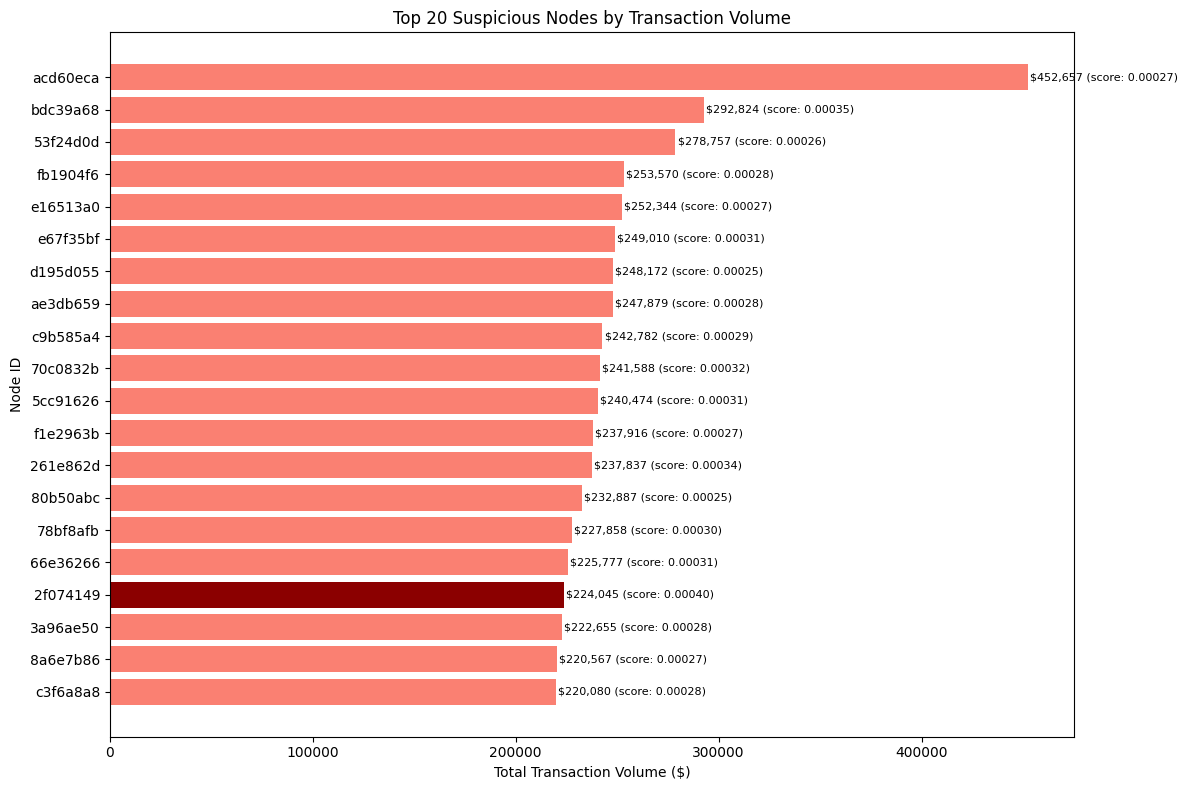

\nTotal money flowing through suspicious nodes: $241,041,061.90


In [11]:
# Top 20 suspicious nodes by transaction volume
top_suspicious_volume = node_money[node_money['is_anomaly'] == True].nlargest(20, 'total_volume')

print("Top 20 Suspicious Nodes by Transaction Volume:")
print("=" * 80)
cols_to_show = ['id', 'total_volume', 'outgoing_amt', 'incoming_amt', 'total_transactions', 'anomaly_score']
if 'is_sar' in top_suspicious_volume.columns:
    cols_to_show.insert(1, 'is_sar')
print(top_suspicious_volume[cols_to_show].to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['darkred' if score > node_money['anomaly_score'].quantile(0.95) else 'salmon' 
          for score in top_suspicious_volume['anomaly_score']]
bars = ax.barh(range(len(top_suspicious_volume)), top_suspicious_volume['total_volume'], color=colors)
ax.set_yticks(range(len(top_suspicious_volume)))
ax.set_yticklabels(top_suspicious_volume['id'])
ax.set_xlabel('Total Transaction Volume ($)')
ax.set_ylabel('Node ID')
ax.set_title('Top 20 Suspicious Nodes by Transaction Volume')
ax.invert_yaxis()

# Add value labels
for i, (v, score) in enumerate(zip(top_suspicious_volume['total_volume'], top_suspicious_volume['anomaly_score'])):
    ax.text(v + 1000, i, f'${v:,.0f} (score: {score:.5f})', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'top_suspicious_by_volume.png'), dpi=150, bbox_inches='tight')
plt.show()

# Total suspicious money
total_suspicious = anomalous_money['total_volume'].sum() / 2  # Divide by 2 to avoid double counting
print(f"\\nTotal money flowing through suspicious nodes: ${total_suspicious:,.2f}")

Money Flow Network Visualization:
  Nodes: 97
  Edges: 31


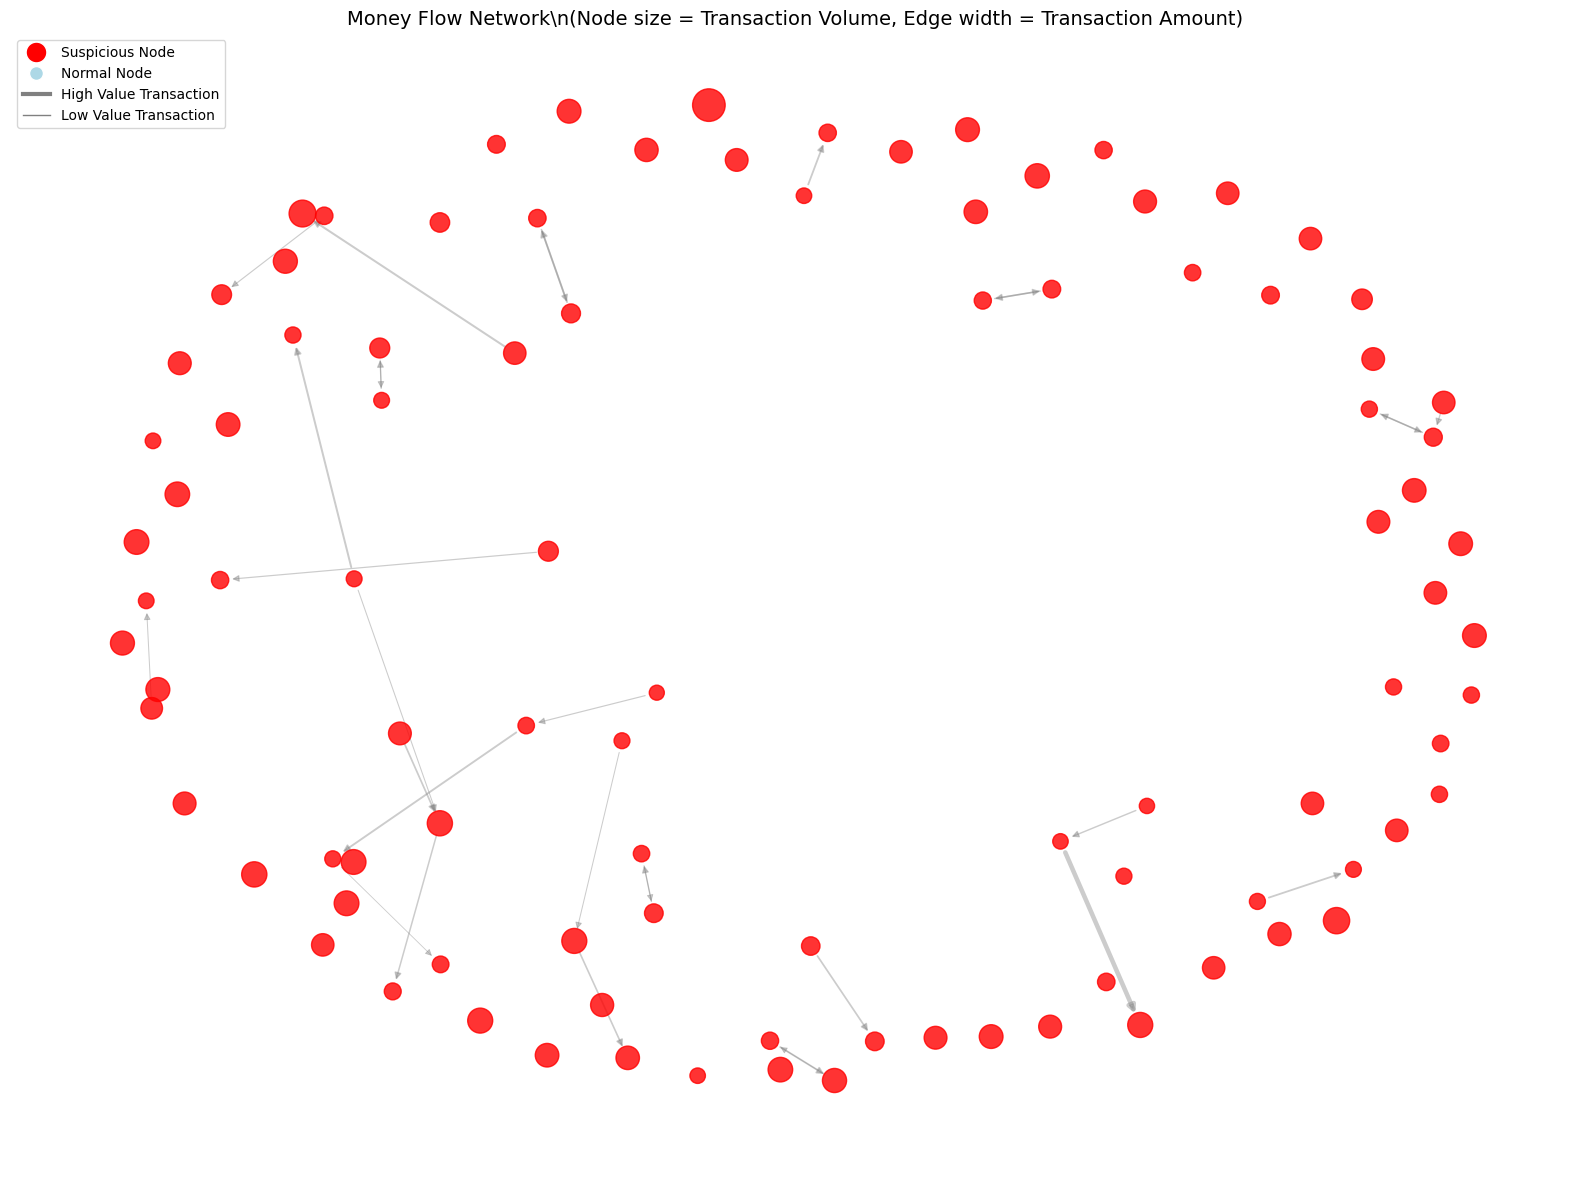

In [12]:
# Money flow network visualization (sampled)
# Create graph with transaction amounts as edge weights
G_money = nx.from_pandas_edgelist(
    edges_df,
    source='source',
    target='target',
    edge_attr='base_amt',
    create_using=nx.DiGraph()
)

# Sample top suspicious nodes for visualization
top_nodes = node_money.nlargest(50, 'total_volume')['id'].tolist()
suspicious_high_volume = node_money[(node_money['is_anomaly']) & (node_money['total_volume'] > node_money['total_volume'].median())]['id'].tolist()[:50]
vis_nodes = set(top_nodes + suspicious_high_volume)

# Get subgraph
G_money_vis = G_money.subgraph([n for n in vis_nodes if n in G_money.nodes()]).copy()

print(f"Money Flow Network Visualization:")
print(f"  Nodes: {G_money_vis.number_of_nodes()}")
print(f"  Edges: {G_money_vis.number_of_edges()}")

# Visualization
fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(G_money_vis, k=3/np.sqrt(G_money_vis.number_of_nodes()), iterations=50, seed=42)

# Node colors based on anomaly status
node_colors_money = []
node_sizes_money = []
node_money_dict = node_money.set_index('id')['total_volume'].to_dict()
node_anomaly_dict = node_money.set_index('id')['is_anomaly'].to_dict()

for node in G_money_vis.nodes():
    is_anom = node_anomaly_dict.get(node, False)
    volume = node_money_dict.get(node, 0)
    
    if is_anom:
        node_colors_money.append('red')
    else:
        node_colors_money.append('lightblue')
    
    # Size based on volume
    node_sizes_money.append(50 + (volume / node_money['total_volume'].max()) * 500)

# Edge widths based on transaction amount
edge_weights = [G_money_vis[u][v]['base_amt'] / edges_df['base_amt'].max() * 3 + 0.5 
                for u, v in G_money_vis.edges()]

# Draw
nx.draw_networkx_edges(G_money_vis, pos, alpha=0.4, edge_color='gray', 
                        width=edge_weights, arrows=True, arrowsize=10, ax=ax)
nx.draw_networkx_nodes(G_money_vis, pos, node_color=node_colors_money, 
                        node_size=node_sizes_money, alpha=0.8, ax=ax)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=15, label='Suspicious Node'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', markersize=10, label='Normal Node'),
    Line2D([0], [0], color='gray', linewidth=3, label='High Value Transaction'),
    Line2D([0], [0], color='gray', linewidth=1, label='Low Value Transaction')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
ax.set_title('Money Flow Network\\n(Node size = Transaction Volume, Edge width = Transaction Amount)', fontsize=14)
ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'money_flow_network.png'), dpi=150, bbox_inches='tight')
plt.show()

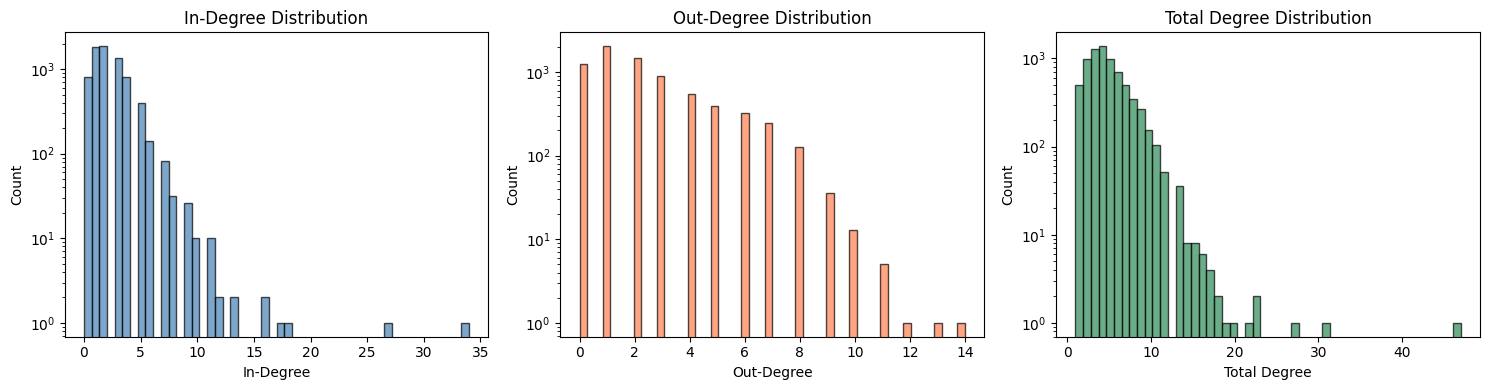


Top 10 nodes by total degree:
  acd60eca: 47
  5cc91626: 31
  6c19333b: 27
  53f24d0d: 23
  0ea0d658: 23
  8a70f08a: 22
  e6465074: 20
  86687c66: 19
  bca39b70: 18
  b0fe7e18: 18


In [13]:
# Calculate node degrees
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
total_degrees = {n: in_degrees.get(n, 0) + out_degrees.get(n, 0) for n in G.nodes()}

# Degree distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(list(in_degrees.values()), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('In-Degree')
axes[0].set_ylabel('Count')
axes[0].set_title('In-Degree Distribution')
axes[0].set_yscale('log')

axes[1].hist(list(out_degrees.values()), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Out-Degree')
axes[1].set_ylabel('Count')
axes[1].set_title('Out-Degree Distribution')
axes[1].set_yscale('log')

axes[2].hist(list(total_degrees.values()), bins=50, color='seagreen', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Total Degree')
axes[2].set_ylabel('Count')
axes[2].set_title('Total Degree Distribution')
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'degree_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 10 nodes by total degree:")
top_degree = sorted(total_degrees.items(), key=lambda x: x[1], reverse=True)[:10]
for node, degree in top_degree:
    print(f"  {node}: {degree}")

## 3. Anomaly Score Analysis

/tmp/ipykernel_96521/1422505265.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([sar_0, sar_1], labels=['Normal (is_sar=0)', 'SAR (is_sar=1)'], patch_artist=True)


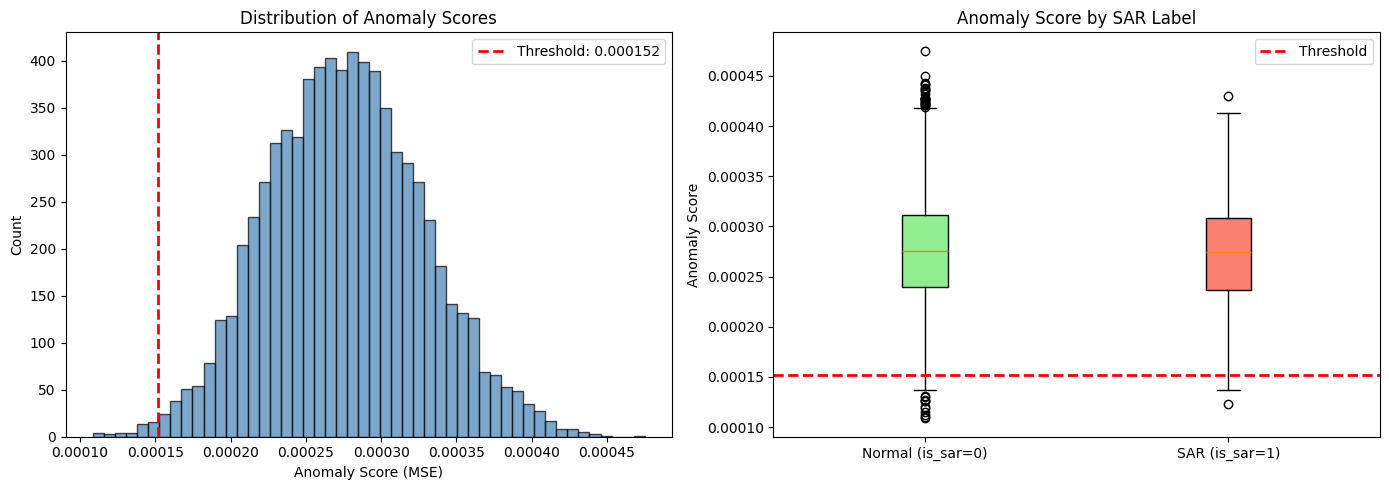

In [14]:
# Anomaly score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(node_embeddings['anomaly_score'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.6f}')
axes[0].set_xlabel('Anomaly Score (MSE)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Anomaly Scores')
axes[0].legend()

# Box plot by is_sar label
if 'is_sar' in node_embeddings.columns:
    sar_0 = node_embeddings[node_embeddings['is_sar'] == 0]['anomaly_score']
    sar_1 = node_embeddings[node_embeddings['is_sar'] == 1]['anomaly_score']
    
    bp = axes[1].boxplot([sar_0, sar_1], labels=['Normal (is_sar=0)', 'SAR (is_sar=1)'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightgreen')
    bp['boxes'][1].set_facecolor('salmon')
    axes[1].axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold')
    axes[1].set_ylabel('Anomaly Score')
    axes[1].set_title('Anomaly Score by SAR Label')
    axes[1].legend()
else:
    normal = node_embeddings[~node_embeddings['is_anomaly']]['anomaly_score']
    anomaly = node_embeddings[node_embeddings['is_anomaly']]['anomaly_score']
    bp = axes[1].boxplot([normal, anomaly], labels=['Normal', 'Anomaly'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightgreen')
    bp['boxes'][1].set_facecolor('salmon')
    axes[1].set_ylabel('Anomaly Score')
    axes[1].set_title('Anomaly Score Distribution')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'anomaly_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Summary statistics
total_nodes = len(node_embeddings)
anomaly_count = node_embeddings['is_anomaly'].sum()
normal_count = total_nodes - anomaly_count

print("=" * 50)
print("ANOMALY DETECTION SUMMARY")
print("=" * 50)
print(f"Total nodes analyzed: {total_nodes}")
print(f"Anomalies detected:   {anomaly_count} ({100*anomaly_count/total_nodes:.1f}%)")
print(f"Normal nodes:         {normal_count} ({100*normal_count/total_nodes:.1f}%)")
print(f"\nAnomaly threshold:    {threshold:.6f}")
print(f"Mean anomaly score:   {node_embeddings['anomaly_score'].mean():.6f}")
print(f"Median anomaly score: {node_embeddings['anomaly_score'].median():.6f}")
print(f"Std anomaly score:    {node_embeddings['anomaly_score'].std():.6f}")
print("=" * 50)

# If SAR labels exist, show confusion matrix-like stats
if 'is_sar' in node_embeddings.columns:
    sar_nodes = node_embeddings['is_sar'].sum()
    detected_sar = ((node_embeddings['is_sar'] == 1) & (node_embeddings['is_anomaly'])).sum()
    print(f"\nSAR Labels in data:   {sar_nodes}")
    print(f"SAR detected as anomaly: {detected_sar} ({100*detected_sar/max(sar_nodes,1):.1f}%)")

ANOMALY DETECTION SUMMARY
Total nodes analyzed: 7347
Anomalies detected:   7304 (99.4%)
Normal nodes:         43 (0.6%)

Anomaly threshold:    0.000152
Mean anomaly score:   0.000276
Median anomaly score: 0.000275
Std anomaly score:    0.000052

SAR Labels in data:   816
SAR detected as anomaly: 808 (99.0%)


## 4. Visualize Transaction Network Graph

In [16]:
# For large graphs, sample a subset for visualization
MAX_NODES_VIS = 500

if G.number_of_nodes() > MAX_NODES_VIS:
    print(f"Graph too large ({G.number_of_nodes()} nodes), sampling {MAX_NODES_VIS} nodes...")
    
    # Get nodes with anomaly scores
    node_scores = node_embeddings.set_index('id')['anomaly_score'].to_dict()
    
    # Prioritize anomalous nodes and high-degree nodes
    anomalous_nodes = node_embeddings[node_embeddings['is_anomaly']]['id'].tolist()
    anomalous_in_graph = [n for n in anomalous_nodes if n in G.nodes()][:MAX_NODES_VIS//2]
    
    # Add high-degree nodes
    remaining = MAX_NODES_VIS - len(anomalous_in_graph)
    other_nodes = [n for n in G.nodes() if n not in anomalous_in_graph]
    other_by_degree = sorted(other_nodes, key=lambda n: total_degrees.get(n, 0), reverse=True)[:remaining]
    
    selected_nodes = set(anomalous_in_graph + other_by_degree)
    G_vis = G.subgraph(selected_nodes).copy()
    print(f"Visualization subgraph: {G_vis.number_of_nodes()} nodes, {G_vis.number_of_edges()} edges")
else:
    G_vis = G
    print(f"Using full graph for visualization")

Graph too large (7347 nodes), sampling 500 nodes...
Visualization subgraph: 500 nodes, 463 edges


In [17]:
# Create node attributes for visualization
node_scores = node_embeddings.set_index('id')['anomaly_score'].to_dict()
node_anomaly = node_embeddings.set_index('id')['is_anomaly'].to_dict()

# Assign colors based on anomaly status
node_colors = []
node_sizes = []
for node in G_vis.nodes():
    is_anom = node_anomaly.get(node, False)
    score = node_scores.get(node, 0)
    
    if is_anom:
        node_colors.append('red')
        node_sizes.append(100 + score * 100000)  # Larger for higher scores
    else:
        node_colors.append('lightblue')
        node_sizes.append(30)

# Cap node sizes
node_sizes = [min(s, 300) for s in node_sizes]

Computing graph layout (this may take a moment)...


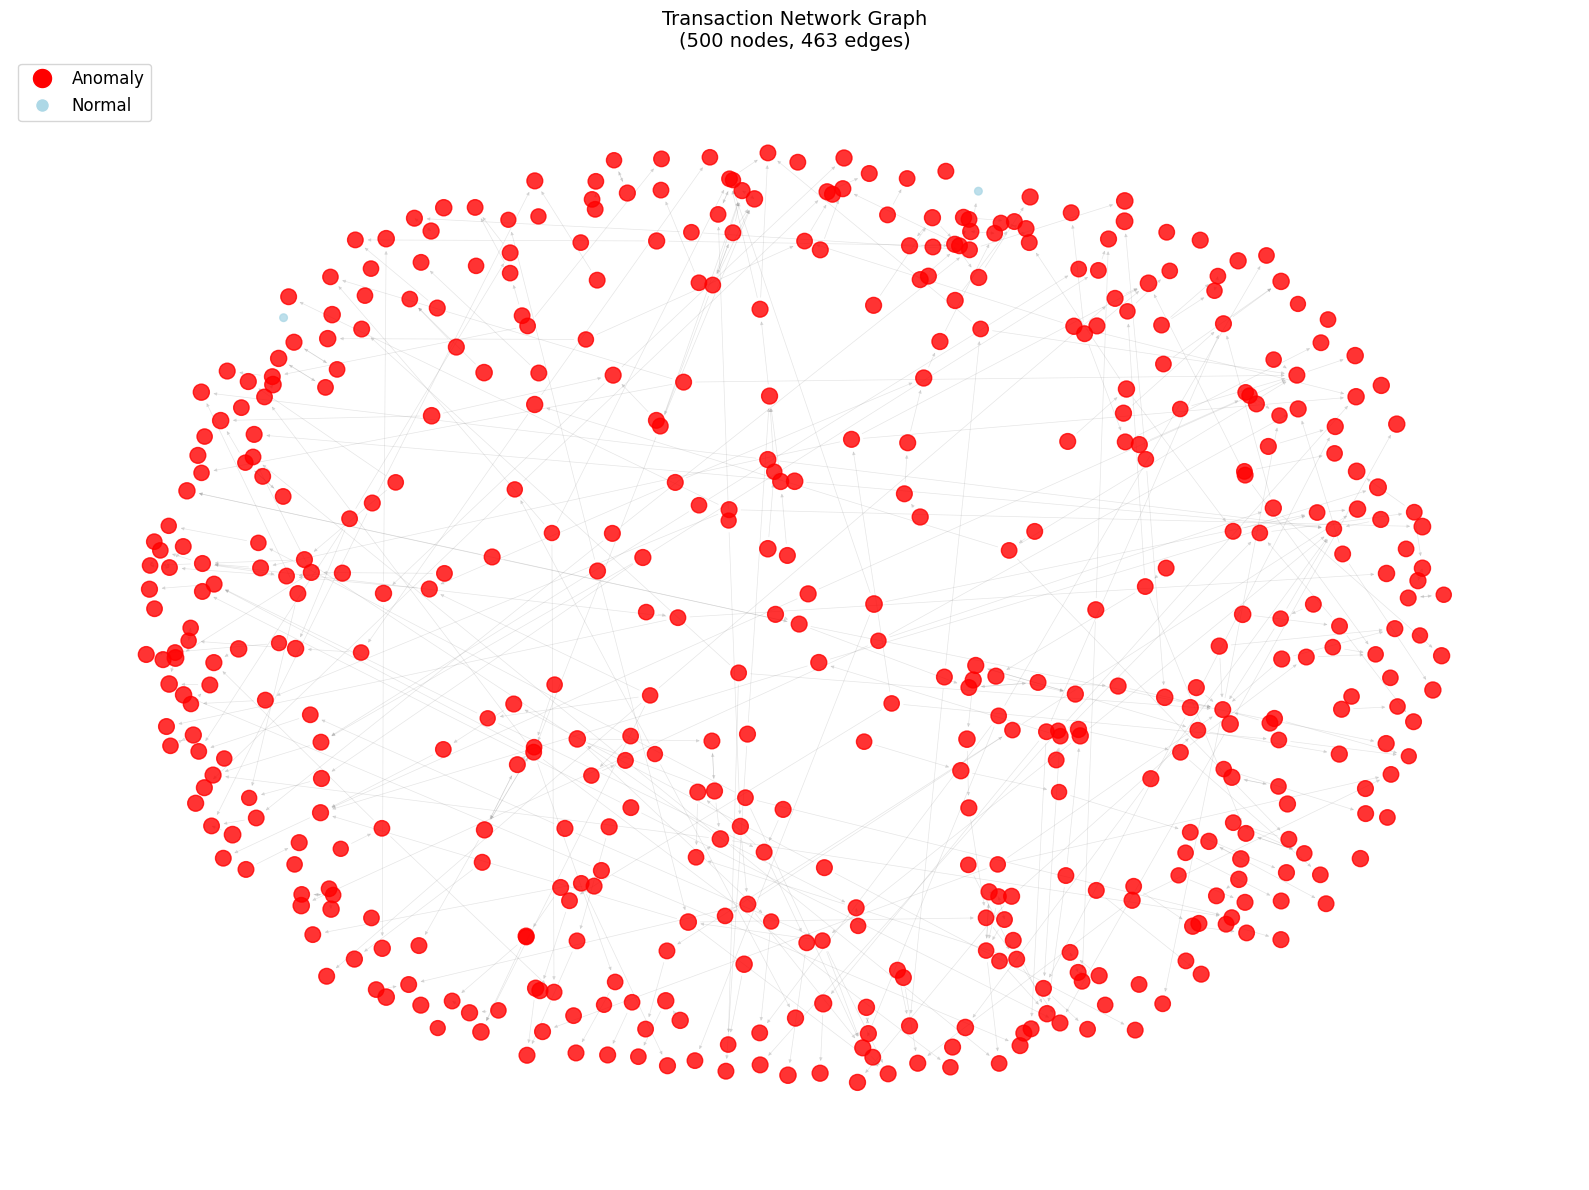

Graph saved to: /home/adnoman/projects/aml_gan/AMLend2end/output/transaction_network.png


In [18]:
# Draw the graph
fig, ax = plt.subplots(figsize=(16, 12))

# Use spring layout for better visualization
print("Computing graph layout (this may take a moment)...")
pos = nx.spring_layout(G_vis, k=2/np.sqrt(G_vis.number_of_nodes()), iterations=50, seed=42)

# Draw edges
nx.draw_networkx_edges(G_vis, pos, alpha=0.2, edge_color='gray', arrows=True, 
                        arrowsize=5, width=0.5, ax=ax)

# Draw nodes
nx.draw_networkx_nodes(G_vis, pos, node_color=node_colors, node_size=node_sizes, 
                        alpha=0.8, ax=ax)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=15, label='Anomaly'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', markersize=10, label='Normal')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12)

ax.set_title(f'Transaction Network Graph\n({G_vis.number_of_nodes()} nodes, {G_vis.number_of_edges()} edges)', 
             fontsize=14)
ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'transaction_network.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Graph saved to: {os.path.join(OUTPUT_PATH, 'transaction_network.png')}")

## 5. Top Anomalous Nodes Analysis

Top 20 Most Anomalous Nodes:
      id  is_sar  anomaly_score  is_anomaly
4b39d278       0       0.000475        True
4b5b8c4d       0       0.000450        True
abc254ca       0       0.000443        True
1ee92071       0       0.000442        True
28635253       0       0.000441        True
bd909974       0       0.000437        True
ada20247       0       0.000437        True
0f117894       0       0.000435        True
38caf6b6       0       0.000435        True
f2dce2c6       0       0.000432        True
a3351e52       1       0.000430        True
8c324919       0       0.000428        True
c70c6291       0       0.000428        True
4013d336       0       0.000427        True
5c7e252e       0       0.000427        True
5596ac1e       0       0.000427        True
50d09a80       0       0.000426        True
d400ff85       0       0.000425        True
d9db885b       0       0.000424        True
ad360326       0       0.000423        True


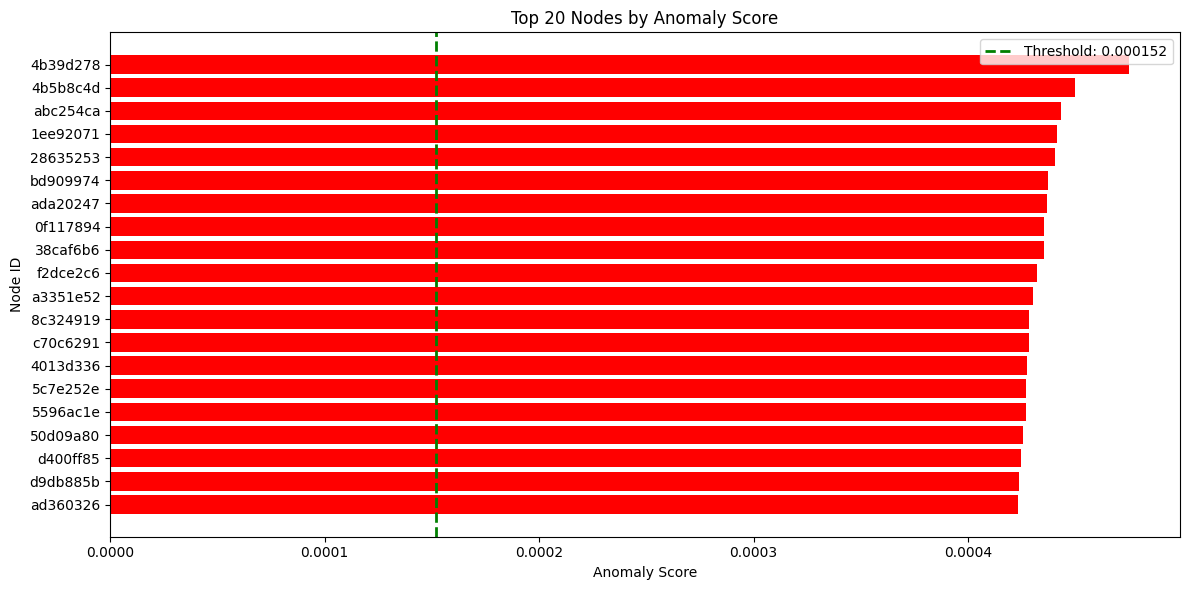

In [19]:
# Top 20 most anomalous nodes
top_anomalies = node_embeddings.nlargest(20, 'anomaly_score')[['id', 'anomaly_score', 'is_anomaly']]
if 'is_sar' in node_embeddings.columns:
    top_anomalies = node_embeddings.nlargest(20, 'anomaly_score')[['id', 'is_sar', 'anomaly_score', 'is_anomaly']]

print("Top 20 Most Anomalous Nodes:")
print("=" * 60)
print(top_anomalies.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['red' if a else 'steelblue' for a in top_anomalies['is_anomaly']]
bars = ax.barh(range(len(top_anomalies)), top_anomalies['anomaly_score'], color=colors)
ax.set_yticks(range(len(top_anomalies)))
ax.set_yticklabels(top_anomalies['id'])
ax.axvline(x=threshold, color='green', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.6f}')
ax.set_xlabel('Anomaly Score')
ax.set_ylabel('Node ID')
ax.set_title('Top 20 Nodes by Anomaly Score')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'top_anomalies.png'), dpi=150, bbox_inches='tight')
plt.show()


Subgraph around top anomaly '4b39d278':
  Nodes: 52
  Edges: 61


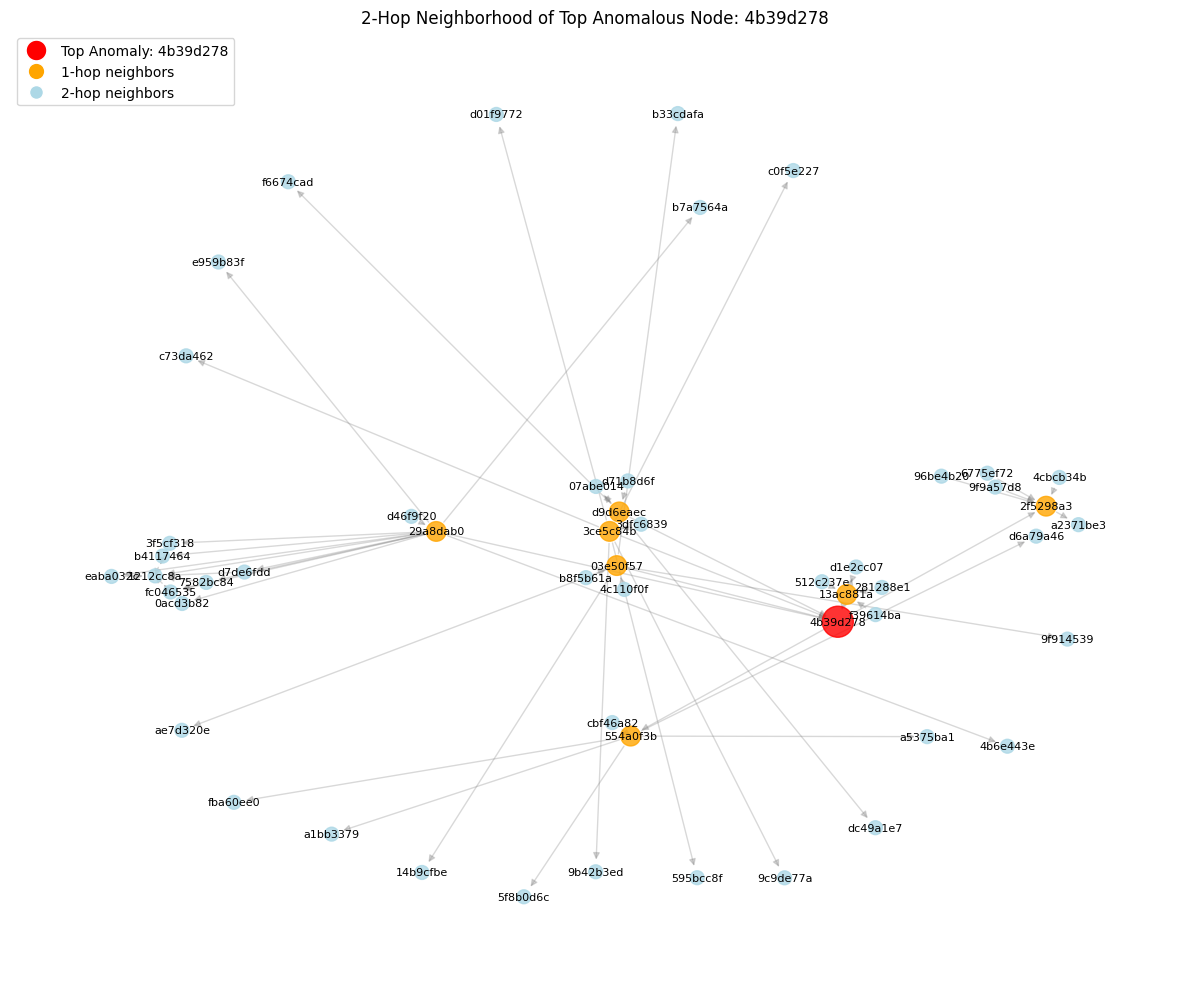

In [20]:
# Visualize subgraph around top anomalous node
top_node = top_anomalies.iloc[0]['id']

if top_node in G.nodes():
    # Get 2-hop neighborhood
    neighbors_1 = set(G.predecessors(top_node)) | set(G.successors(top_node))
    neighbors_2 = set()
    for n in neighbors_1:
        neighbors_2 |= set(G.predecessors(n)) | set(G.successors(n))
    
    subgraph_nodes = {top_node} | neighbors_1 | neighbors_2
    G_sub = G.subgraph(subgraph_nodes).copy()
    
    print(f"\nSubgraph around top anomaly '{top_node}':")
    print(f"  Nodes: {G_sub.number_of_nodes()}")
    print(f"  Edges: {G_sub.number_of_edges()}")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(12, 10))
    pos = nx.spring_layout(G_sub, seed=42)
    
    # Color nodes
    colors = []
    sizes = []
    for node in G_sub.nodes():
        if node == top_node:
            colors.append('red')
            sizes.append(500)
        elif node in neighbors_1:
            colors.append('orange')
            sizes.append(200)
        else:
            colors.append('lightblue')
            sizes.append(100)
    
    nx.draw_networkx_edges(G_sub, pos, alpha=0.3, edge_color='gray', arrows=True, ax=ax)
    nx.draw_networkx_nodes(G_sub, pos, node_color=colors, node_size=sizes, alpha=0.8, ax=ax)
    nx.draw_networkx_labels(G_sub, pos, font_size=8, ax=ax)
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=15, label=f'Top Anomaly: {top_node}'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=12, label='1-hop neighbors'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', markersize=10, label='2-hop neighbors')
    ]
    ax.legend(handles=legend_elements, loc='upper left')
    ax.set_title(f"2-Hop Neighborhood of Top Anomalous Node: {top_node}")
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, 'top_anomaly_neighborhood.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"Node {top_node} not found in graph")

## 6. Summary Report

In [21]:
# Final summary with money statistics
print("\n" + "=" * 70)
print(" AML ANOMALY DETECTION - VISUALIZATION REPORT ")
print("=" * 70)

print(f"\n{'Graph Statistics':^40}")
print("-" * 40)
print(f"  Total Nodes:          {G.number_of_nodes():,}")
print(f"  Total Edges:          {G.number_of_edges():,}")
print(f"  Graph Density:        {nx.density(G):.6f}")
print(f"  Avg Degree:           {sum(total_degrees.values())/len(total_degrees):.2f}")

print(f"\n{'Transaction Value Statistics':^40}")
print("-" * 40)
print(f"  Total Transactions:   {len(edges_df):,}")
print(f"  Total Value:          ${edges_df['base_amt'].sum():,.2f}")
print(f"  Average Transaction:  ${edges_df['base_amt'].mean():,.2f}")
print(f"  Max Transaction:      ${edges_df['base_amt'].max():,.2f}")

print(f"\n{'Anomaly Detection Results':^40}")
print("-" * 40)
print(f"  Nodes Analyzed:       {len(node_embeddings):,}")
print(f"  Anomalies Detected:   {node_embeddings['is_anomaly'].sum():,} ({100*node_embeddings['is_anomaly'].mean():.1f}%)")
print(f"  Detection Threshold:  {threshold:.6f}")
print(f"  Max Anomaly Score:    {node_embeddings['anomaly_score'].max():.6f}")

print(f"\n{'Suspicious Money Flow':^40}")
print("-" * 40)
suspicious_volume = node_money[node_money['is_anomaly']]['total_volume'].sum() / 2
total_volume = edges_df['base_amt'].sum()
print(f"  Suspicious Volume:    ${suspicious_volume:,.2f}")
print(f"  % of Total Volume:    {100*suspicious_volume/total_volume:.1f}%")
print(f"  Avg per Suspicious:   ${node_money[node_money['is_anomaly']]['total_volume'].mean():,.2f}")

print(f"\n{'Output Files':^40}")
print("-" * 40)
print(f"  - degree_distribution.png")
print(f"  - anomaly_distribution.png")
print(f"  - transaction_network.png")
print(f"  - top_anomalies.png")
print(f"  - top_anomaly_neighborhood.png")
print(f"  - transaction_amounts.png")
print(f"  - money_flow_comparison.png")
print(f"  - top_suspicious_by_volume.png")
print(f"  - money_flow_network.png")

print("\n" + "=" * 70)
print(" VISUALIZATION COMPLETE! ")
print("=" * 70)


 AML ANOMALY DETECTION - VISUALIZATION REPORT 

            Graph Statistics            
----------------------------------------
  Total Nodes:          7,347
  Total Edges:          17,070
  Graph Density:        0.000316
  Avg Degree:           4.65

      Transaction Value Statistics      
----------------------------------------
  Total Transactions:   438,386
  Total Value:          $242,434,979.01
  Average Transaction:  $553.02
  Max Transaction:      $2,995.02

       Anomaly Detection Results        
----------------------------------------
  Nodes Analyzed:       7,347
  Anomalies Detected:   7,304 (99.4%)
  Detection Threshold:  0.000152
  Max Anomaly Score:    0.000475

         Suspicious Money Flow          
----------------------------------------
  Suspicious Volume:    $241,041,061.90
  % of Total Volume:    99.4%
  Avg per Suspicious:   $66,002.48

              Output Files              
----------------------------------------
  - degree_distribution.png
  - anoma